In [4]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from fairlearn.metrics import (
    MetricFrame,
    false_positive_rate,
    true_positive_rate,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference
)

In [5]:
possible_files = [
    "fairface_label_val.csv",
    "fairface_label_train.csv",
    "fairface_label_validation.csv"
]

found_files = [f for f in possible_files if os.path.exists(f)]

if not found_files:
    found_files = glob.glob("*.csv")

print("CSV files found:", found_files)

if len(found_files) == 0:
    raise FileNotFoundError("No CSV file found in the current folder.")

DATA_PATH = found_files[0]
print("Using file:", DATA_PATH)

CSV files found: ['fairface_label_val.csv']
Using file: fairface_label_val.csv


In [6]:
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (10954, 5)


,file,age,gender,race,service_test
0,val/1.jpg,3-9,Male,East Asian,False
1,val/2.jpg,50-59,Female,East Asian,True
2,val/3.jpg,30-39,Male,White,True
3,val/4.jpg,20-29,Female,Latino_Hispanic,True
4,val/5.jpg,20-29,Male,Southeast Asian,False


In [7]:
print("Original columns:")
print(df_raw.columns.tolist())

Original columns:
['file', 'age', 'gender', 'race', 'service_test']


In [8]:
df = df_raw.copy()
df.columns = df.columns.str.strip().str.lower()

print("Standardized columns:")
print(df.columns.tolist())

Standardized columns:
['file', 'age', 'gender', 'race', 'service_test']


In [9]:
required_columns = ["race", "gender"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Required column '{col}' not found in the FairFace label file.")

print("Required columns found.")

Required columns found.


In [10]:
df["race"] = df["race"].astype(str).str.strip().str.lower()
df["gender"] = df["gender"].astype(str).str.strip().str.lower()


df["group"] = df["race"]

gender_map = {
    "male": 1,
    "female": 0
}
df["y_true"] = df["gender"].map(gender_map)

df = df.dropna(subset=["group", "y_true"]).copy()
df["y_true"] = df["y_true"].astype(int)

df = df.drop_duplicates()

print("Cleaned shape:", df.shape)
df[["group", "gender", "y_true"]].head()

Cleaned shape: (10954, 7)


,group,gender,y_true
0,east asian,male,1
1,east asian,female,0
2,white,male,1
3,latino_hispanic,female,0
4,southeast asian,male,1


group
black              1556
east asian         1550
indian             1516
latino_hispanic    1623
middle eastern     1209
southeast asian    1415
white              2085
Name: count, dtype: int64


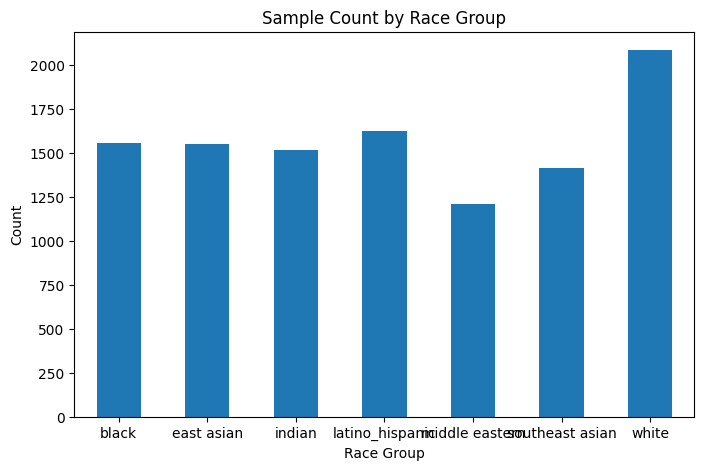

In [11]:
group_counts = df["group"].value_counts().sort_index()
print(group_counts)

plt.figure(figsize=(8, 5))
group_counts.plot(kind="bar")
plt.title("Sample Count by Race Group")
plt.xlabel("Race Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [12]:
label_distribution = pd.crosstab(df["group"], df["y_true"], margins=True)
label_distribution

y_true,0,1,All
group,,,
black,757,799,1556
east asian,773,777,1550
indian,763,753,1516
latino_hispanic,830,793,1623
middle eastern,396,813,1209
southeast asian,680,735,1415
white,963,1122,2085
All,5162,5792,10954


In [13]:
np.random.seed(42)


error_rate_by_group = {
    "white": 0.10,
    "black": 0.18,
    "east asian": 0.14,
    "southeast asian": 0.15,
    "indian": 0.13,
    "middle eastern": 0.12,
    "latino_hispanic": 0.16
}

default_error_rate = 0.14

error_rates = df["group"].map(lambda x: error_rate_by_group.get(x, default_error_rate))


flip = np.random.binomial(1, error_rates, size=len(df))


df["y_pred"] = np.where(flip == 1, 1 - df["y_true"], df["y_true"])

base_score = np.where(df["y_true"] == 1, 0.75, 0.25)
noise = np.random.normal(0, 0.15, size=len(df))
df["score"] = np.clip(base_score + noise, 0, 1)

df[["group", "y_true", "y_pred", "score"]].head()

,group,y_true,y_pred,score
0,east asian,1,1,0.992557
1,east asian,0,1,0.134436
2,white,1,1,0.921504
3,latino_hispanic,0,0,0.277729
4,southeast asian,1,1,0.787829


In [14]:
audit_df = df[["group", "y_true", "y_pred", "score"]].copy()
audit_df.to_csv("facial_fairness_audit.csv", index=False)

print("Saved final analysis file: facial_fairness_audit.csv")
audit_df.head()

Saved final analysis file: facial_fairness_audit.csv


,group,y_true,y_pred,score
0,east asian,1,1,0.992557
1,east asian,0,1,0.134436
2,white,1,1,0.921504
3,latino_hispanic,0,0,0.277729
4,southeast asian,1,1,0.787829


In [15]:
overall_metrics = {
    "accuracy": accuracy_score(audit_df["y_true"], audit_df["y_pred"]),
    "precision": precision_score(audit_df["y_true"], audit_df["y_pred"], zero_division=0),
    "recall": recall_score(audit_df["y_true"], audit_df["y_pred"], zero_division=0),
    "f1": f1_score(audit_df["y_true"], audit_df["y_pred"], zero_division=0)
}

overall_metrics_df = pd.DataFrame([overall_metrics])
overall_metrics_df

,accuracy,precision,recall,f1
0,0.865437,0.882395,0.860152,0.871131


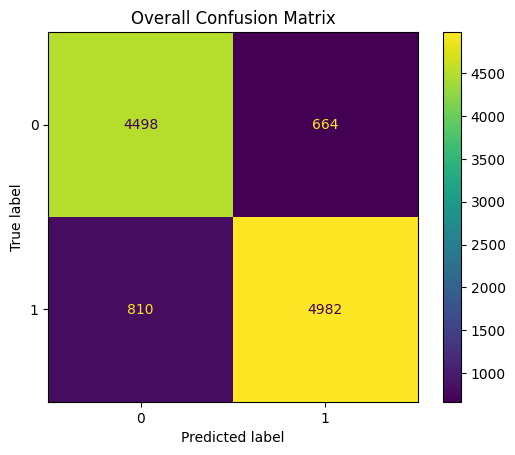

In [16]:
cm = confusion_matrix(audit_df["y_true"], audit_df["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Overall Confusion Matrix")
plt.show()

In [17]:
metrics = {
    "accuracy": accuracy_score,
    "precision": lambda y_true, y_pred: precision_score(y_true, y_pred, zero_division=0),
    "recall": lambda y_true, y_pred: recall_score(y_true, y_pred, zero_division=0),
    "false_positive_rate": false_positive_rate,
    "true_positive_rate": true_positive_rate,
    "selection_rate": selection_rate
}

mf = MetricFrame(
    metrics=metrics,
    y_true=audit_df["y_true"],
    y_pred=audit_df["y_pred"],
    sensitive_features=audit_df["group"]
)

by_group_metrics = mf.by_group.reset_index()
by_group_metrics

,group,accuracy,precision,recall,false_positive_rate,true_positive_rate,selection_rate
0,black,0.807841,0.818878,0.803504,0.187583,0.803504,0.503856
1,east asian,0.864516,0.866753,0.862291,0.133247,0.862291,0.498710
2,indian,0.884565,0.891599,0.873838,0.104849,0.873838,0.486807
3,latino_hispanic,0.846580,0.850515,0.832282,0.139759,0.832282,0.478127
4,middle eastern,0.887510,0.948344,0.880689,0.098485,0.880689,0.624483
5,southeast asian,0.858657,0.868966,0.857143,0.139706,0.857143,0.512367
6,white,0.901679,0.918721,0.896613,0.092420,0.896613,0.525180


In [18]:
print("Overall metrics:")
print(mf.overall)

print("\nMetrics by group:")
print(mf.by_group)

Overall metrics:
accuracy               0.865437
precision              0.882395
recall                 0.860152
false_positive_rate    0.128632
true_positive_rate     0.860152
selection_rate         0.515428
dtype: float64

Metrics by group:
                 accuracy  precision    recall  false_positive_rate  \
group                                                                 
black            0.807841   0.818878  0.803504             0.187583   
east asian       0.864516   0.866753  0.862291             0.133247   
indian           0.884565   0.891599  0.873838             0.104849   
latino_hispanic  0.846580   0.850515  0.832282             0.139759   
middle eastern   0.887510   0.948344  0.880689             0.098485   
southeast asian  0.858657   0.868966  0.857143             0.139706   
white            0.901679   0.918721  0.896613             0.092420   

                 true_positive_rate  selection_rate  
group                                                
black    

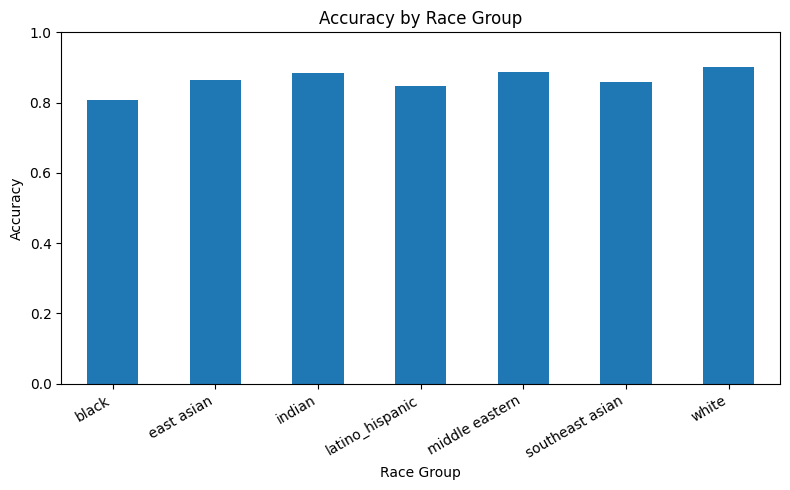

In [19]:
plt.figure(figsize=(8, 5))
mf.by_group["accuracy"].sort_index().plot(kind="bar")
plt.title("Accuracy by Race Group")
plt.xlabel("Race Group")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

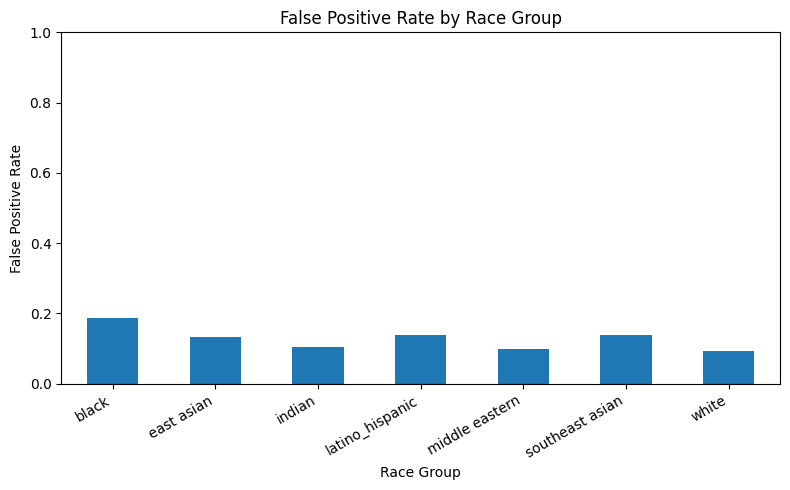

In [20]:
plt.figure(figsize=(8, 5))
mf.by_group["false_positive_rate"].sort_index().plot(kind="bar")
plt.title("False Positive Rate by Race Group")
plt.xlabel("Race Group")
plt.ylabel("False Positive Rate")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

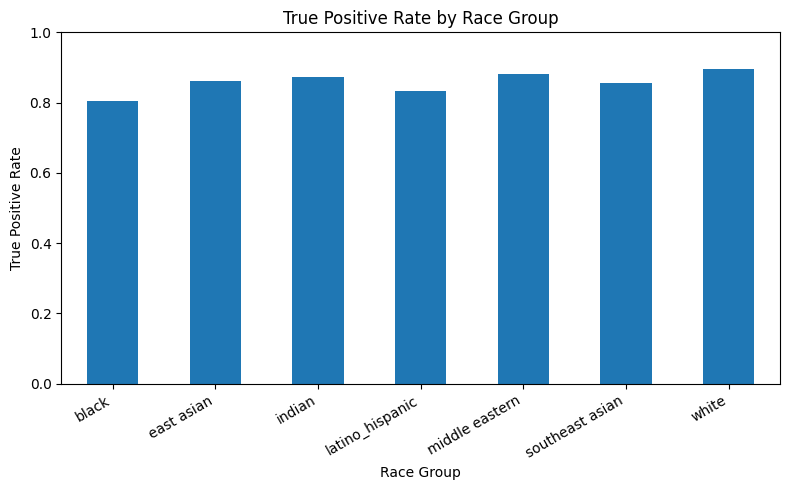

In [21]:
plt.figure(figsize=(8, 5))
mf.by_group["true_positive_rate"].sort_index().plot(kind="bar")
plt.title("True Positive Rate by Race Group")
plt.xlabel("Race Group")
plt.ylabel("True Positive Rate")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

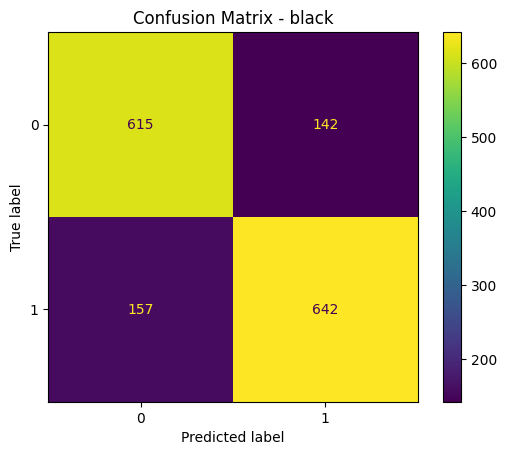

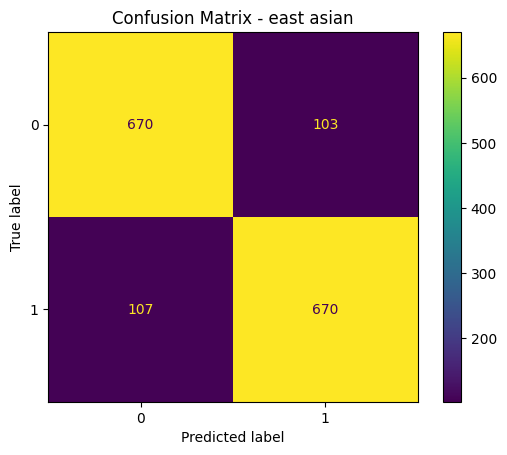

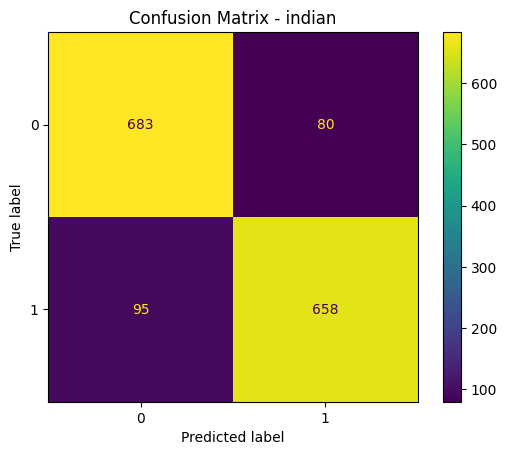

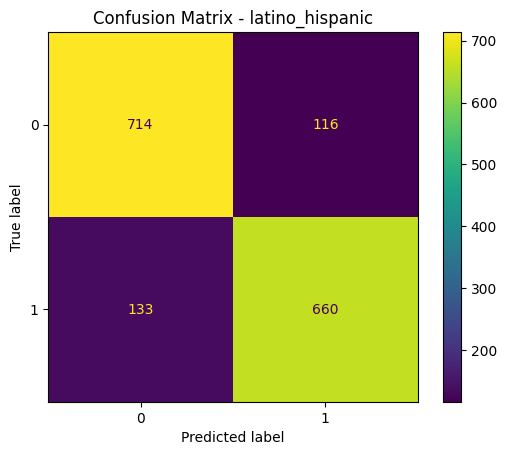

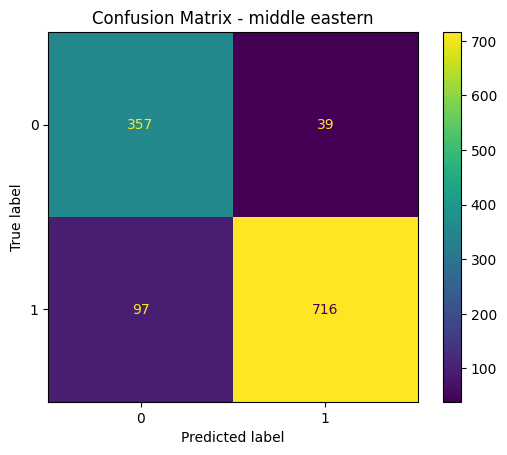

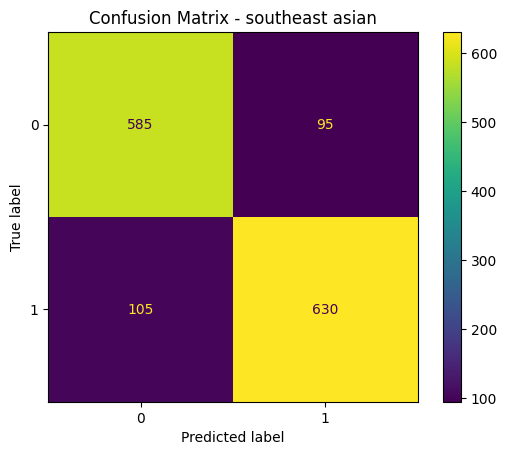

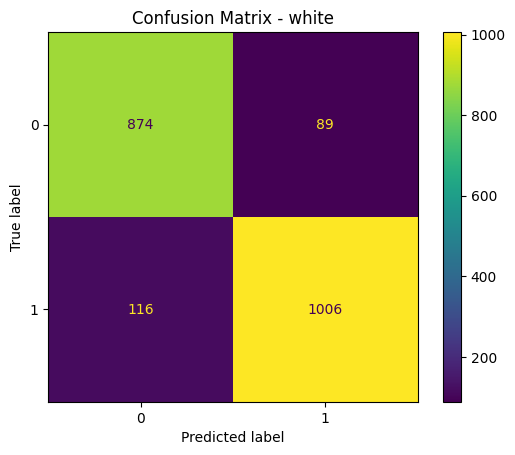

In [22]:
groups = sorted(audit_df["group"].unique())

for g in groups:
    sub = audit_df[audit_df["group"] == g]
    cm_g = confusion_matrix(sub["y_true"], sub["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_g)
    disp.plot()
    plt.title(f"Confusion Matrix - {g}")
    plt.show()

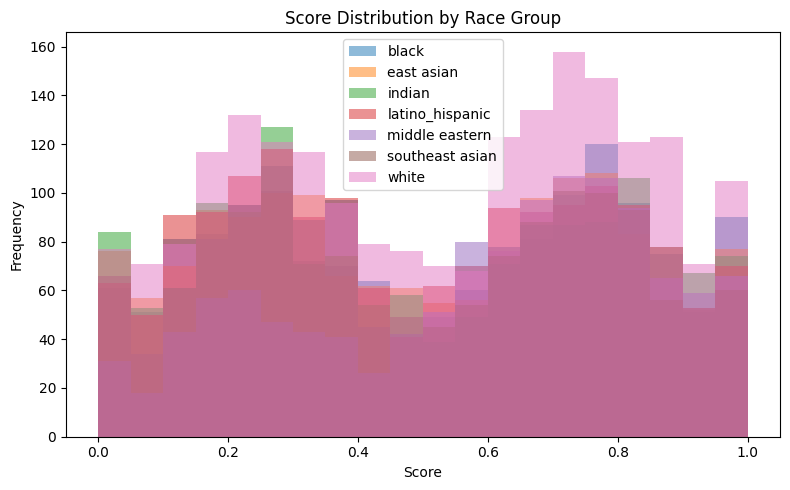

In [23]:
plt.figure(figsize=(8, 5))

for g in sorted(audit_df["group"].unique()):
    sub = audit_df[audit_df["group"] == g]
    plt.hist(sub["score"], bins=20, alpha=0.5, label=g)

plt.title("Score Distribution by Race Group")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
dp_diff = demographic_parity_difference(
    y_true=audit_df["y_true"],
    y_pred=audit_df["y_pred"],
    sensitive_features=audit_df["group"]
)

eo_diff = equalized_odds_difference(
    y_true=audit_df["y_true"],
    y_pred=audit_df["y_pred"],
    sensitive_features=audit_df["group"]
)

fairness_summary = pd.DataFrame([{
    "demographic_parity_difference": dp_diff,
    "equalized_odds_difference": eo_diff
}])

fairness_summary

,demographic_parity_difference,equalized_odds_difference
0,0.146356,0.095163


In [25]:
acc_by_group = mf.by_group["accuracy"]
fpr_by_group = mf.by_group["false_positive_rate"]
tpr_by_group = mf.by_group["true_positive_rate"]

summary_dict = {
    "highest_accuracy_group": acc_by_group.idxmax(),
    "highest_accuracy_value": acc_by_group.max(),
    "lowest_accuracy_group": acc_by_group.idxmin(),
    "lowest_accuracy_value": acc_by_group.min(),
    "highest_fpr_group": fpr_by_group.idxmax(),
    "highest_fpr_value": fpr_by_group.max(),
    "lowest_fpr_group": fpr_by_group.idxmin(),
    "lowest_fpr_value": fpr_by_group.min(),
    "highest_tpr_group": tpr_by_group.idxmax(),
    "highest_tpr_value": tpr_by_group.max(),
    "lowest_tpr_group": tpr_by_group.idxmin(),
    "lowest_tpr_value": tpr_by_group.min()
}

summary_dict

{'highest_accuracy_group': 'white',
 'highest_accuracy_value': 0.9016786570743405,
 'lowest_accuracy_group': 'black',
 'lowest_accuracy_value': 0.8078406169665809,
 'highest_fpr_group': 'black',
 'highest_fpr_value': 0.18758256274768825,
 'lowest_fpr_group': 'white',
 'lowest_fpr_value': 0.09241952232606439,
 'highest_tpr_group': 'white',
 'highest_tpr_value': 0.8966131907308378,
 'lowest_tpr_group': 'black',
 'lowest_tpr_value': 0.8035043804755945}

In [26]:
report_paragraph = f"""
This fairness audit used the FairFace label file to construct a reproducible proxy prediction setting
for subgroup performance evaluation. The highest subgroup accuracy was observed for the
{summary_dict['highest_accuracy_group']} group ({summary_dict['highest_accuracy_value']:.3f}),
while the lowest subgroup accuracy was observed for the {summary_dict['lowest_accuracy_group']} group
({summary_dict['lowest_accuracy_value']:.3f}).

The highest false positive rate was found for the {summary_dict['highest_fpr_group']} group
({summary_dict['highest_fpr_value']:.3f}). In a high-stakes context such as law enforcement,
a higher false positive rate is especially concerning because it increases the risk of incorrect
flagging and unequal scrutiny.

The equalized odds difference was {eo_diff:.3f}, which indicates that performance was not evenly
distributed across demographic groups. This result shows why subgroup fairness analysis is necessary
and why aggregate accuracy alone is not sufficient to support responsible deployment.
"""

print(report_paragraph)


This fairness audit used the FairFace label file to construct a reproducible proxy prediction setting
for subgroup performance evaluation. The highest subgroup accuracy was observed for the
white group (0.902),
while the lowest subgroup accuracy was observed for the black group
(0.808).

The highest false positive rate was found for the black group
(0.188). In a high-stakes context such as law enforcement,
a higher false positive rate is especially concerning because it increases the risk of incorrect
flagging and unequal scrutiny.

The equalized odds difference was 0.095, which indicates that performance was not evenly
distributed across demographic groups. This result shows why subgroup fairness analysis is necessary
and why aggregate accuracy alone is not sufficient to support responsible deployment.



In [27]:
overall_metrics_df.to_csv("overall_metrics.csv", index=False)
by_group_metrics.to_csv("by_group_metrics.csv", index=False)
fairness_summary.to_csv("fairness_summary.csv", index=False)

print("Saved files:")
print("- facial_fairness_audit.csv")
print("- overall_metrics.csv")
print("- by_group_metrics.csv")
print("- fairness_summary.csv")

Saved files:
- facial_fairness_audit.csv
- overall_metrics.csv
- by_group_metrics.csv
- fairness_summary.csv
